In [ ]:
!pip install ultralytics tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.9 MB/s eta 0:00:00


In [ ]:
# Import all required libraries
import os
import random
import numpy as np
from PIL import Image, ImageEnhance
import shutil
from collections import defaultdict
import yaml
from ultralytics import YOLO
import torch
from google.colab import drive

# Classification imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully!


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

def setup_and_collect_celebrities():
    """Setup drive access and collect all celebrity data"""
    print("COLLECTING ALL CELEBRITY DATA")
    print("="*50)

    dataset_path = "/content/drive/MyDrive/Celebrity Image Subsets"

    if not os.path.exists(dataset_path):
        print(f"ERROR: Dataset path does not exist: {dataset_path}")
        return None, [], []

    print(f"Dataset path confirmed: {dataset_path}")

    # Get all celebrity folders
    all_folders = os.listdir(dataset_path)
    celebrity_folders = [f for f in all_folders if f.startswith('images_<') and f.endswith('>')]

    print(f"Found {len(celebrity_folders)} celebrity folders")

    celebrity_images = defaultdict(list)
    found_celebrities = []
    total_images = 0

    for folder in celebrity_folders:
        # Extract celebrity ID: images_<ID> -> ID
        celeb_id = folder.replace('images_<', '').replace('>', '')
        folder_path = os.path.join(dataset_path, folder)

        try:
            if os.path.isdir(folder_path):
                # Get all image files
                image_files = [f for f in os.listdir(folder_path)
                              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

                if image_files:
                    full_paths = [os.path.join(folder_path, img) for img in image_files]
                    celebrity_images[celeb_id] = full_paths
                    found_celebrities.append(celeb_id)
                    total_images += len(full_paths)
                    print(f"Celebrity {celeb_id}: {len(full_paths)} images")
                else:
                    print(f"Celebrity {celeb_id}: no images found")
        except Exception as e:
            print(f"Error processing {folder}: {e}")

    print(f"\nCOLLECTION COMPLETE:")
    print(f"Found {len(found_celebrities)} celebrities")
    print(f"Total source images: {total_images}")
    print(f"Celebrity IDs: {sorted(found_celebrities)}")

    return celebrity_images, found_celebrities, dataset_path

# Execute the collection
celebrity_images, found_celebrities, dataset_path = setup_and_collect_celebrities()

if celebrity_images is None:
    print("Failed to collect celebrity data - check your dataset path")
else:
    print(f"\nReady to proceed with {len(found_celebrities)} celebrities!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLLECTING ALL CELEBRITY DATA
Dataset path confirmed: /content/drive/MyDrive/Celebrity Image Subsets
Found 48 celebrity folders
Celebrity 8968: 32 images
Celebrity 3227: 35 images
Celebrity 2820: 35 images
Celebrity 3782: 36 images
Celebrity 8722: 30 images
Celebrity 3401: 18 images
Celebrity 2880: 30 images
Celebrity 9256: 100 images
Celebrity 9152: 100 images
Celebrity 3699: 100 images
Celebrity 3745: 100 images
Celebrity 3431: 30 images
Celebrity 1499: 30 images
Celebrity 8045: 30 images
Celebrity 8656: 30 images
Celebrity 9319: 25 images
Celebrity 4126: 30 images
Celebrity 3321: 18 images
Celebrity 2463: 30 images
Celebrity 4304: 30 images
Celebrity 2425: 30 images
Celebrity 1158: 24 images
Celebrity 6098: 20 images
Celebrity 9151: 30 images
Celebrity 2562: no images found
Celebrity 6568: 31 images
Celebrity 800: 30 images
Celebrity 228: 21 images
Celebri

In [ ]:
def create_balanced_classification_dataset(celebrity_images, target_images_per_celeb=150):
    """Create a balanced dataset with extensive augmentation"""
    print("CREATING BALANCED CLASSIFICATION DATASET WITH EXTENSIVE AUGMENTATION")
    print("="*70)

    balanced_dataset_dir = "/content/balanced_celebrity_classification"
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(balanced_dataset_dir, split), exist_ok=True)

    def advanced_augment_image(img, augmentation_level='medium'):
        """Apply comprehensive augmentation to a single image"""
        augmented_images = []

        # Base transformations - always apply
        base_transforms = [
            # Brightness variations
            lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.6, 1.4)),
            # Contrast variations
            lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)),
            # Color saturation
            lambda x: ImageEnhance.Color(x).enhance(random.uniform(0.8, 1.2)),
            # Sharpness
            lambda x: ImageEnhance.Sharpness(x).enhance(random.uniform(0.8, 1.2)),
        ]

        # Geometric transformations
        geometric_transforms = [
            # Horizontal flip
            lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),
            # Rotation variations
            lambda x: x.rotate(random.uniform(-20, 20), fillcolor='white'),
            lambda x: x.rotate(random.uniform(-10, 10), fillcolor='white'),
            lambda x: x.rotate(random.uniform(-30, 30), fillcolor='white'),
        ]

        # Create multiple variations
        for i in range(8 if augmentation_level == 'high' else 5):
            aug_img = img.copy()

            # Apply 2-4 random base transforms
            num_base = random.randint(2, 4)
            selected_base = random.sample(base_transforms, num_base)
            for transform in selected_base:
                aug_img = transform(aug_img)

            # Sometimes apply geometric transform
            if random.random() > 0.4:
                geo_transform = random.choice(geometric_transforms)
                aug_img = geo_transform(aug_img)

            # Random crop and resize (slight variations)
            if random.random() > 0.6:
                width, height = aug_img.size
                crop_margin = int(min(width, height) * 0.05)  # 5% margin
                left = random.randint(0, crop_margin)
                top = random.randint(0, crop_margin)
                right = width - random.randint(0, crop_margin)
                bottom = height - random.randint(0, crop_margin)
                aug_img = aug_img.crop((left, top, right, bottom))
                aug_img = aug_img.resize((224, 224))
            else:
                aug_img = aug_img.resize((224, 224))

            augmented_images.append(aug_img)

        return augmented_images

    balanced_stats = {}

    for celeb_id, source_images in celebrity_images.items():
        if len(source_images) == 0:
            continue

        print(f"Processing Celebrity {celeb_id}: {len(source_images)} -> {target_images_per_celeb} images")

        # Create celebrity folders
        for split in ['train', 'val', 'test']:
            os.makedirs(os.path.join(balanced_dataset_dir, split, f"celeb_{celeb_id}"), exist_ok=True)

        # Generate required number of images
        all_generated_images = []

        # Calculate augmentation level based on original count
        if len(source_images) < 20:
            aug_level = 'high'
        elif len(source_images) < 50:
            aug_level = 'medium'
        else:
            aug_level = 'low'

        while len(all_generated_images) < target_images_per_celeb:
            for source_path in source_images:
                if len(all_generated_images) >= target_images_per_celeb:
                    break

                try:
                    # Load source image
                    img = Image.open(source_path).convert('RGB')

                    # Add original (resized)
                    orig_resized = img.resize((224, 224))
                    all_generated_images.append(orig_resized)

                    if len(all_generated_images) >= target_images_per_celeb:
                        break

                    # Add augmented versions
                    augmented = advanced_augment_image(img, aug_level)
                    for aug_img in augmented:
                        if len(all_generated_images) < target_images_per_celeb:
                            all_generated_images.append(aug_img)
                        else:
                            break

                except Exception as e:
                    print(f"  Error processing {source_path}: {e}")
                    continue

        # Shuffle all generated images
        random.shuffle(all_generated_images)

        # Split into train/val/test
        n_test = int(len(all_generated_images) * 0.15)  # 15% test
        n_val = int(len(all_generated_images) * 0.15)   # 15% validation
        n_train = len(all_generated_images) - n_test - n_val  # 70% train

        train_images = all_generated_images[:n_train]
        val_images = all_generated_images[n_train:n_train + n_val]
        test_images = all_generated_images[n_train + n_val:]

        # Save images
        def save_image_list(img_list, target_dir, celeb_id):
            saved = 0
            for i, img in enumerate(img_list):
                try:
                    filename = f"celeb_{celeb_id}_{i:04d}.jpg"
                    filepath = os.path.join(target_dir, f"celeb_{celeb_id}", filename)
                    img.save(filepath, quality=92)
                    saved += 1
                except Exception as e:
                    print(f"    Error saving image {i}: {e}")
            return saved

        train_saved = save_image_list(train_images, os.path.join(balanced_dataset_dir, "train"), celeb_id)
        val_saved = save_image_list(val_images, os.path.join(balanced_dataset_dir, "val"), celeb_id)
        test_saved = save_image_list(test_images, os.path.join(balanced_dataset_dir, "test"), celeb_id)

        balanced_stats[celeb_id] = {
            'original': len(source_images),
            'train': train_saved,
            'val': val_saved,
            'test': test_saved,
            'total': train_saved + val_saved + test_saved
        }

        print(f"  Saved: {train_saved} train, {val_saved} val, {test_saved} test")

    total_generated = sum(stats['total'] for stats in balanced_stats.values())
    print(f"\nBALANCED DATASET COMPLETE:")
    print(f"  Total images generated: {total_generated}")
    print(f"  Average per celebrity: {total_generated // len(balanced_stats)}")
    print(f"  Number of classes: {len(balanced_stats)}")

    return balanced_dataset_dir, balanced_stats

# Create the balanced dataset (replaces the old function call)
balanced_dataset_dir, balanced_stats = create_balanced_classification_dataset(
    celebrity_images, target_images_per_celeb=150
)

# Update the variables for the rest of the pipeline
class_dataset_dir = balanced_dataset_dir
class_stats = balanced_stats

CREATING BALANCED CLASSIFICATION DATASET WITH EXTENSIVE AUGMENTATION
Processing Celebrity 8968: 32 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3227: 35 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 2820: 35 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3782: 36 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 8722: 30 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3401: 18 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 2880: 30 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 9256: 100 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 9152: 100 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3699: 100 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3745: 100 -> 150 images
  Saved: 106 train, 22 val, 22 test
Processing Celebrity 3431: 30 -> 150 images
  S

In [ ]:
def create_basic_cnn(num_classes, input_shape=(224, 224, 3)):
    """Create a basic CNN model"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def create_transfer_learning_model(num_classes, base_model_name='VGG16'):
    """Create transfer learning model"""
    from tensorflow.keras.applications import VGG16, ResNet50

    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze base model initially
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Model architectures defined successfully!")

Model architectures defined successfully!


In [ ]:
def train_classification_models(dataset_dir, num_classes):
    """Train multiple classification models and compare them"""
    print("TRAINING CLASSIFICATION MODELS")
    print("="*50)

    # Data generators with augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    # Create data generators
    train_generator = train_datagen.flow_from_directory(
        os.path.join(balanced_dataset_dir, 'train'),  # Use balanced dataset
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

    val_generator = val_datagen.flow_from_directory(
        os.path.join(balanced_dataset_dir, 'val'),    # Use balanced dataset
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)

    models_to_train = {
        'Basic_CNN': create_basic_cnn(num_classes),
        'VGG16_Transfer': create_transfer_learning_model(num_classes, 'VGG16'),
        'ResNet50_Transfer': create_transfer_learning_model(num_classes, 'ResNet50')
    }

    trained_models = {}
    training_histories = {}

    for model_name, model in models_to_train.items():
        print(f"\nTraining {model_name}...")
        print(f"Model parameters: {model.count_params():,}")

        # Train model
        history = model.fit(
          train_generator,
          epochs=50,  # Increased from 20
          validation_data=val_generator,
          callbacks=[
              EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
              ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=8),  # More aggressive LR reduction
          ]
        )

        trained_models[model_name] = model
        training_histories[model_name] = history

        # Save model
        model_path = f"/content/celebrity_classifier_{model_name.lower()}.h5"
        model.save(model_path)
        print(f"Model saved: {model_path}")

    return trained_models, training_histories, train_generator.class_indices

# Train the models
num_classes = len([c for c, stats in class_stats.items() if stats['total'] > 0])
print(f"Training models for {num_classes} classes...")

trained_models, histories, class_indices = train_classification_models(class_dataset_dir, num_classes)

Training models for 47 classes...
TRAINING CLASSIFICATION MODELS
Found 4982 images belonging to 47 classes.
Found 1034 images belonging to 47 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training Basic_CNN...
Model parameters: 19,408,623


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 93s 511ms/step - accuracy: 0.0284 - loss: 9.2225 - val_accuracy: 0.0164 - val_loss: 3.8918 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 70s 448ms/step - accuracy: 0.0190 - loss: 3.9788 - val_accuracy: 0.0213 - val_loss: 3.8589 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 442ms/step - accuracy: 0.0218 - loss: 3.8631 - val_accuracy: 0.0222 - val_loss: 3.8986 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 441ms/step - accuracy: 0.0178 - loss: 3.8755 - val_accuracy: 0.0203 - val_loss: 3.8442 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 443ms/step - accuracy: 0.0241 - loss: 3.8743 - val_accuracy: 0.0251 - val_loss: 3.8488 - learning_rate: 0.0010
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 70s 446ms/step - accuracy: 0.0242 - loss: 3.8631 - val_accuracy: 0.0126 - val_loss: 3.8505 - learning_rate: 0.0010
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 437ms/step - accuracy: 0.0

Model saved: /content/celebrity_classifier_basic_cnn.h5

Training VGG16_Transfer...
Model parameters: 15,120,751
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 122s 654ms/step - accuracy: 0.0214 - loss: 3.9708 - val_accuracy: 0.0464 - val_loss: 3.8282 - learning_rate: 1.0000e-04
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 85s 547ms/step - accuracy: 0.0201 - loss: 3.8732 - val_accuracy: 0.0754 - val_loss: 3.8072 - learning_rate: 1.0000e-04
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 81s 518ms/step - accuracy: 0.0278 - loss: 3.8349 - val_accuracy: 0.0986 - val_loss: 3.7798 - learning_rate: 1.0000e-04
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 81s 520ms/step - accuracy: 0.0382 - loss: 3.8121 - val_accuracy: 0.1460 - val_loss: 3.7307 - learning_rate: 1.0000e-04
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 81s 520ms/step - accuracy: 0.0442 - loss: 3.7693 - val_accuracy: 0.1586 - val_loss: 3.6546 - learning_rate: 1.0000e-04
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 85s 547ms/step - accuracy: 0.0608 - loss: 3.6993 - 

Model saved: /content/celebrity_classifier_vgg16_transfer.h5

Training ResNet50_Transfer...
Model parameters: 24,780,207
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 101s 550ms/step - accuracy: 0.0239 - loss: 4.1212 - val_accuracy: 0.0145 - val_loss: 3.8529 - learning_rate: 1.0000e-04
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 71s 457ms/step - accuracy: 0.0178 - loss: 3.9000 - val_accuracy: 0.0203 - val_loss: 3.8507 - learning_rate: 1.0000e-04
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 73s 466ms/step - accuracy: 0.0262 - loss: 3.8648 - val_accuracy: 0.0261 - val_loss: 3.8500 - learning_rate: 1.0000e-04
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 70s 447ms/step - accuracy: 0.0237 - loss: 3.8578 - val_accuracy: 0.0242 - val_loss: 3.8493 - learning_rate: 1.0000e-04
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 443ms/step - accuracy: 0.0187 - loss: 3.8586 - val_accuracy: 0.0251 - val_loss: 3.8486 - learning_rate: 1.0000e-04
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 441ms/step - accuracy: 0.0225 - loss: 3

Model saved: /content/celebrity_classifier_resnet50_transfer.h5


In [ ]:
def evaluate_classification_models(trained_models, dataset_dir, class_indices):
    """Evaluate and compare all trained models"""
    print("EVALUATING CLASSIFICATION MODELS")
    print("="*50)

    # Test data generator
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        os.path.join(balanced_dataset_dir, 'test'),  # Use balanced dataset
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    evaluation_results = {}

    for model_name, model in trained_models.items():
        print(f"\nEvaluating {model_name}...")

        # Get predictions
        test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
        predictions = model.predict(test_generator, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = test_generator.classes

        # Classification report
        class_names = list(class_indices.keys())
        report = classification_report(true_classes, predicted_classes,
                                     target_names=class_names, output_dict=True)

        evaluation_results[model_name] = {
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'classification_report': report,
            'predictions': predictions,
            'predicted_classes': predicted_classes,
            'true_classes': true_classes
        }

        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

        # Per-class accuracy
        per_class_acc = []
        for class_name in class_names:
            if class_name in report:
                per_class_acc.append(report[class_name]['f1-score'])

        print(f"Average F1-Score: {np.mean(per_class_acc):.4f}")

    # Select best model
    best_model_name = max(evaluation_results.keys(),
                         key=lambda x: evaluation_results[x]['test_accuracy'])

    print(f"\nBEST MODEL: {best_model_name}")
    print(f"Accuracy: {evaluation_results[best_model_name]['test_accuracy']:.4f}")

    return evaluation_results, best_model_name

# Evaluate all models
evaluation_results, best_model_name = evaluate_classification_models(trained_models, class_dataset_dir, class_indices)
best_classification_model = trained_models[best_model_name]

# Save best model to Drive
best_model_drive_path = f"/content/drive/MyDrive/best_celebrity_classifier_{best_model_name}.h5"
best_classification_model.save(best_model_drive_path)
print(f"Best model saved to Drive: {best_model_drive_path}")

EVALUATING CLASSIFICATION MODELS
Found 1034 images belonging to 47 classes.

Evaluating Basic_CNN...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy: 0.0261
Test Loss: 4.5223
Average F1-Score: 0.0020

Evaluating VGG16_Transfer...
Test Accuracy: 0.5996
Test Loss: 1.5764
Average F1-Score: 0.5842

Evaluating ResNet50_Transfer...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy: 0.0426
Test Loss: 3.7988
Average F1-Score: 0.0149

BEST MODEL: VGG16_Transfer
Accuracy: 0.5996
Best model saved to Drive: /content/drive/MyDrive/best_celebrity_classifier_VGG16_Transfer.h5


In [ ]:
def create_augmented_image(source_path, output_folder, celeb_id, index):
    """Create single augmented image"""
    try:
        img = Image.open(source_path)
        img = img.resize((200, 250))  # Standard size

        # Apply random augmentations
        transformations = []

        # Brightness (70% to 130%)
        if random.random() > 0.3:
            factor = random.uniform(0.7, 1.3)
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(factor)
            transformations.append("brightness")

        # Contrast (80% to 120%)
        if random.random() > 0.3:
            factor = random.uniform(0.8, 1.2)
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(factor)
            transformations.append("contrast")

        # Color saturation (80% to 120%)
        if random.random() > 0.4:
            factor = random.uniform(0.8, 1.2)
            enhancer = ImageEnhance.Color(img)
            img = enhancer.enhance(factor)
            transformations.append("color")

        # Horizontal flip
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            transformations.append("flip")

        # Slight rotation (-15 to +15 degrees)
        if random.random() > 0.6:
            angle = random.uniform(-15, 15)
            img = img.rotate(angle, fillcolor='white', expand=False)
            transformations.append("rotate")

        # Save augmented image
        output_path = os.path.join(output_folder, f"celeb_{celeb_id}_{index:03d}.jpg")
        img.save(output_path, quality=90)

        return output_path

    except Exception as e:
        return None

def create_individual_augmented_datasets(celebrity_images, images_per_celebrity=100):
    """Create augmented individual celebrity datasets"""
    print("CREATING INDIVIDUAL AUGMENTED DATASETS")
    print("="*50)

    individual_dir = "/content/individual_celebrity_augmented"
    os.makedirs(individual_dir, exist_ok=True)

    augmented_celebrity_dict = {}

    for celeb_id, source_images in celebrity_images.items():
        if not source_images:
            continue

        print(f"Processing Celebrity {celeb_id}...")

        # Create folder for this celebrity
        celeb_folder = os.path.join(individual_dir, f"Celebrity_{celeb_id}")
        os.makedirs(celeb_folder, exist_ok=True)

        augmented_images = []

        # Create augmented versions
        for i in range(images_per_celebrity):
            # Select random source image
            source_img = random.choice(source_images)

            try:
                augmented_path = create_augmented_image(source_img, celeb_folder, celeb_id, i)
                if augmented_path:
                    augmented_images.append(augmented_path)
            except Exception as e:
                print(f"  Error creating augmented image {i}: {e}")

        augmented_celebrity_dict[celeb_id] = augmented_images
        print(f"  Created {len(augmented_images)} augmented images")

    total_augmented = sum(len(imgs) for imgs in augmented_celebrity_dict.values())
    print(f"\nTotal augmented images created: {total_augmented}")

    return augmented_celebrity_dict

# Create individual augmented datasets
augmented_celebrity_dict = create_individual_augmented_datasets(celebrity_images, images_per_celebrity=100)

CREATING INDIVIDUAL AUGMENTED DATASETS
Processing Celebrity 8968...
  Created 100 augmented images
Processing Celebrity 3227...
  Created 100 augmented images
Processing Celebrity 2820...
  Created 100 augmented images
Processing Celebrity 3782...
  Created 100 augmented images
Processing Celebrity 8722...
  Created 100 augmented images
Processing Celebrity 3401...
  Created 100 augmented images
Processing Celebrity 2880...
  Created 100 augmented images
Processing Celebrity 9256...
  Created 100 augmented images
Processing Celebrity 9152...
  Created 100 augmented images
Processing Celebrity 3699...
  Created 100 augmented images
Processing Celebrity 3745...
  Created 100 augmented images
Processing Celebrity 3431...
  Created 100 augmented images
Processing Celebrity 1499...
  Created 100 augmented images
Processing Celebrity 8045...
  Created 100 augmented images
Processing Celebrity 8656...
  Created 100 augmented images
Processing Celebrity 9319...
  Created 100 augmented images
P

In [ ]:
def create_composite_image(celebrity_data, selected_celebs, output_size=(640, 640)):
    """Create composite image from selected celebrities"""
    composite = Image.new('RGB', output_size, (255, 255, 255))
    positions_info = []

    # Position templates for different numbers of celebrities
    position_templates = {
        2: [(80, 150), (360, 150)],
        3: [(80, 100), (360, 100), (220, 350)],
        4: [(80, 50), (360, 50), (80, 340), (360, 340)]
    }

    positions = position_templates.get(len(selected_celebs), position_templates[3])

    for i, celeb_id in enumerate(selected_celebs):
        if i >= len(positions):
            break

        try:
            # Get random image for this celebrity
            celeb_images = celebrity_data[celeb_id]
            if not celeb_images:
                continue

            selected_image_path = random.choice(celeb_images)
            celeb_img = Image.open(selected_image_path)

            # Position with randomness
            base_x, base_y = positions[i]
            x = base_x + random.randint(-30, 30)
            y = base_y + random.randint(-30, 30)

            # Ensure image fits within bounds
            x = max(0, min(x, output_size[0] - 200))
            y = max(0, min(y, output_size[1] - 250))

            # Paste celebrity image
            composite.paste(celeb_img, (x, y))

            # Store position info
            positions_info.append({
                'celebrity_id': celeb_id,
                'position': (x, y),
                'bbox': (x, y, x + 200, y + 250)
            })

        except Exception as e:
            print(f"Error adding celebrity {celeb_id}: {e}")
            continue

    return composite, positions_info

def create_multi_celebrity_composites(augmented_celebrity_dict, num_composites=1200):
    """Create multi-celebrity composite images"""
    print("CREATING MULTI-CELEBRITY COMPOSITE IMAGES")
    print("="*50)

    celebrity_ids = list(augmented_celebrity_dict.keys())
    print(f"Creating composites from {len(celebrity_ids)} celebrities")

    composite_dir = "/content/composite_images"
    annotations_dir = "/content/composite_annotations"
    os.makedirs(composite_dir, exist_ok=True)
    os.makedirs(annotations_dir, exist_ok=True)

    successful_composites = 0

    for i in range(num_composites):
        try:
            # Randomly choose 2-4 celebrities for this composite
            num_celebs = random.choice([2, 3, 4])
            if len(celebrity_ids) < num_celebs:
                num_celebs = len(celebrity_ids)

            selected_celebs = random.sample(celebrity_ids, num_celebs)

            # Create composite image
            composite, positions_info = create_composite_image(
                augmented_celebrity_dict, selected_celebs
            )

            if len(positions_info) > 0:
                # Save composite image
                comp_filename = f"composite_{i:04d}.jpg"
                comp_path = os.path.join(composite_dir, comp_filename)
                composite.save(comp_path, quality=95)

                # Save annotations
                ann_filename = f"composite_{i:04d}.txt"
                ann_path = os.path.join(annotations_dir, ann_filename)

                with open(ann_path, 'w') as f:
                    f.write(f"# Composite image with {len(positions_info)} celebrities\n")
                    f.write("# Format: celebrity_id, x1, y1, x2, y2\n")
                    for pos_info in positions_info:
                        bbox = pos_info['bbox']
                        f.write(f"{pos_info['celebrity_id']},{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}\n")

                successful_composites += 1

            # Progress update
            if (i + 1) % 200 == 0:
                print(f"Progress: {i + 1}/{num_composites} ({successful_composites} successful)")

        except Exception as e:
            print(f"Error creating composite {i}: {e}")

    print(f"Successfully created {successful_composites} composite images")
    return successful_composites, composite_dir, annotations_dir

# Create multi-celebrity composites
num_composites, composite_dir, annotations_dir = create_multi_celebrity_composites(
    augmented_celebrity_dict, num_composites=1200
)

CREATING MULTI-CELEBRITY COMPOSITE IMAGES
Creating composites from 47 celebrities
Progress: 200/1200 (200 successful)
Progress: 400/1200 (400 successful)
Progress: 600/1200 (600 successful)
Progress: 800/1200 (800 successful)
Progress: 1000/1200 (1000 successful)
Progress: 1200/1200 (1200 successful)
Successfully created 1200 composite images


In [ ]:
def augment_image_with_coordinate_transform(image_path, annotation_path):
    """Augment image and transform coordinates accordingly"""
    try:
        img = Image.open(image_path)

        # Load annotations
        annotations = []
        with open(annotation_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('#') or not line:
                    continue
                parts = line.split(',')
                if len(parts) >= 5:
                    celebrity_id = parts[0]
                    x1, y1, x2, y2 = map(int, parts[1:5])
                    annotations.append({
                        'celebrity_id': celebrity_id,
                        'bbox': (x1, y1, x2, y2)
                    })

        # Apply augmentations
        transformed_annotations = []
        applied_transformations = []

        # Brightness adjustment
        if random.random() > 0.3:
            factor = random.uniform(0.8, 1.2)
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(factor)
            applied_transformations.append("brightness")

        # Contrast adjustment
        if random.random() > 0.3:
            factor = random.uniform(0.9, 1.1)
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(factor)
            applied_transformations.append("contrast")

        # Horizontal flip with coordinate transformation
        flip_applied = False
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            flip_applied = True
            applied_transformations.append("horizontal_flip")

        # Transform annotations
        for ann in annotations:
            if flip_applied:
                # Transform coordinates for horizontal flip
                x1, y1, x2, y2 = ann['bbox']
                image_width = img.width
                new_x1 = image_width - x2
                new_x2 = image_width - x1
                new_bbox = (new_x1, y1, new_x2, y2)
            else:
                new_bbox = ann['bbox']

            transformed_annotations.append({
                'celebrity_id': ann['celebrity_id'],
                'bbox': new_bbox
            })

        return img, transformed_annotations

    except Exception as e:
        print(f"Error in augmentation: {e}")
        return None, None

def augment_composites_with_coordinate_transform(composite_dir, annotations_dir, num_augmentations=3):
    """Augment composite images with proper coordinate transformation"""
    print("AUGMENTING COMPOSITES WITH COORDINATE TRANSFORMATION")
    print("="*50)

    final_images_dir = "/content/final_multi_celebrity_dataset/images"
    final_annotations_dir = "/content/final_multi_celebrity_dataset/annotations"
    os.makedirs(final_images_dir, exist_ok=True)
    os.makedirs(final_annotations_dir, exist_ok=True)

    # Copy original composites first
    composite_files = [f for f in os.listdir(composite_dir) if f.endswith('.jpg')]

    total_final_images = 0

    for comp_file in composite_files:
        # Copy original image and annotation
        src_img = os.path.join(composite_dir, comp_file)
        dst_img = os.path.join(final_images_dir, comp_file)
        shutil.copy2(src_img, dst_img)

        ann_file = comp_file.replace('.jpg', '.txt')
        src_ann = os.path.join(annotations_dir, ann_file)
        dst_ann = os.path.join(final_annotations_dir, ann_file)
        if os.path.exists(src_ann):
            shutil.copy2(src_ann, dst_ann)

        total_final_images += 1

        # Create augmented versions
        base_name = os.path.splitext(comp_file)[0]

        for aug_idx in range(num_augmentations):
            try:
                augmented_img, transformed_annotations = augment_image_with_coordinate_transform(
                    src_img, src_ann
                )

                if augmented_img and transformed_annotations:
                    # Save augmented image
                    aug_filename = f"{base_name}_aug_{aug_idx}.jpg"
                    aug_img_path = os.path.join(final_images_dir, aug_filename)
                    augmented_img.save(aug_img_path, quality=90)

                    # Save transformed annotations
                    aug_ann_filename = f"{base_name}_aug_{aug_idx}.txt"
                    aug_ann_path = os.path.join(final_annotations_dir, aug_ann_filename)

                    with open(aug_ann_path, 'w') as f:
                        f.write("# Augmented composite image\n")
                        f.write("# Format: celebrity_id, x1, y1, x2, y2\n")
                        for ann in transformed_annotations:
                            bbox = ann['bbox']
                            f.write(f"{ann['celebrity_id']},{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}\n")

                    total_final_images += 1

            except Exception as e:
                print(f"Error augmenting {comp_file}: {e}")

    print(f"Final dataset created with {total_final_images} images")
    return total_final_images, final_images_dir, final_annotations_dir

# Augment composites with coordinate transformation
total_images, final_images_dir, final_annotations_dir = augment_composites_with_coordinate_transform(
    composite_dir, annotations_dir, num_augmentations=3
)

AUGMENTING COMPOSITES WITH COORDINATE TRANSFORMATION
Final dataset created with 4800 images


In [ ]:
def convert_to_yolo_format(images_dir, annotations_dir, output_dir, celebrity_ids):
    """Convert dataset to YOLO format"""
    print("CONVERTING TO YOLO FORMAT")
    print("="*50)

    celeb_id_to_class = {celeb_id: idx for idx, celeb_id in enumerate(celebrity_ids)}

    # Create YOLO directory structure
    train_images_dir = os.path.join(output_dir, "train", "images")
    train_labels_dir = os.path.join(output_dir, "train", "labels")
    val_images_dir = os.path.join(output_dir, "val", "images")
    val_labels_dir = os.path.join(output_dir, "val", "labels")

    for path in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
        os.makedirs(path, exist_ok=True)

    # Get all files
    annotation_files = sorted([f for f in os.listdir(annotations_dir) if f.endswith('.txt')])

    # Split 80-20
    split_idx = int(len(annotation_files) * 0.8)
    train_files = annotation_files[:split_idx]
    val_files = annotation_files[split_idx:]

    print(f"Converting {len(train_files)} train, {len(val_files)} val files to YOLO format")

    def process_split(files, target_images_dir, target_labels_dir):
        converted = 0
        for ann_file in files:
            img_file = ann_file.replace('.txt', '.jpg')
            img_src = os.path.join(images_dir, img_file)
            ann_src = os.path.join(annotations_dir, ann_file)

            if not os.path.exists(img_src):
                continue

            # Copy image
            shutil.copy2(img_src, os.path.join(target_images_dir, img_file))

            # Convert annotation
            yolo_annotations = []
            with open(ann_src, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line.startswith('#') or not line:
                        continue

                    parts = line.split(',')
                    if len(parts) >= 5:
                        celeb_id = parts[0]
                        x1, y1, x2, y2 = map(int, parts[1:5])

                        if celeb_id in celeb_id_to_class:
                            # Convert to YOLO format (normalized coordinates)
                            x_center = ((x1 + x2) / 2) / 640
                            y_center = ((y1 + y2) / 2) / 640
                            width = (x2 - x1) / 640
                            height = (y2 - y1) / 640

                            class_id = celeb_id_to_class[celeb_id]
                            yolo_annotations.append(f"{class_id} {x_center} {y_center} {width} {height}")

            # Write YOLO annotation file
            if yolo_annotations:
                yolo_ann_path = os.path.join(target_labels_dir, ann_file)
                with open(yolo_ann_path, 'w') as f:
                    f.write('\n'.join(yolo_annotations))
                converted += 1

        return converted

    train_converted = process_split(train_files, train_images_dir, train_labels_dir)
    val_converted = process_split(val_files, val_images_dir, val_labels_dir)

    print(f"Converted {train_converted} train, {val_converted} val files")
    return celeb_id_to_class

def create_yolo_config(output_dir, celebrity_ids, celeb_id_to_class):
    """Create YOLO configuration file"""
    print("CREATING YOLO CONFIGURATION")
    print("="*50)

    config = {
        'path': output_dir,
        'train': 'train/images',
        'val': 'val/images',
        'nc': len(celebrity_ids),
        'names': {idx: celeb_id for celeb_id, idx in celeb_id_to_class.items()}
    }

    config_path = os.path.join(output_dir, 'data.yaml')
    with open(config_path, 'w') as f:
        yaml.dump(config, f, sort_keys=False)

    print(f"YOLO config created: {config_path}")
    print(f"Number of classes: {len(celebrity_ids)}")

    return config_path

# Convert to YOLO format
yolo_dataset_dir = "/content/yolo_final_celebrity_dataset"
celeb_id_to_class = convert_to_yolo_format(
    final_images_dir, final_annotations_dir, yolo_dataset_dir, found_celebrities
)

# Create YOLO configuration
config_path = create_yolo_config(yolo_dataset_dir, found_celebrities, celeb_id_to_class)

CONVERTING TO YOLO FORMAT
Converting 3840 train, 960 val files to YOLO format
Converted 3840 train, 960 val files
CREATING YOLO CONFIGURATION
YOLO config created: /content/yolo_final_celebrity_dataset/data.yaml
Number of classes: 47


In [ ]:
def train_yolo_model_final(config_path, celebrity_list, epochs=25):
    """Train final YOLO model with all celebrities"""
    print("TRAINING YOLO MODEL WITH ALL CELEBRITIES")
    print("="*60)
    print(f"Training with {len(celebrity_list)} classes...")
    print("="*60)

    # Load and train model
    model = YOLO('yolov8n.pt')

    # Check device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Training device: {device}")

    # Training parameters
    results = model.train(
        data=config_path,
        epochs=epochs,
        imgsz=640,
        batch=16,
        device=device,
        patience=20,
        save=True,
        plots=True,
        name='celebrity_final_detection',
        exist_ok=True,
        verbose=True
    )

    # Save final model
    final_model_path = "/content/celebrity_final_detector.pt"
    shutil.copy2("runs/detect/celebrity_final_detection/weights/best.pt", final_model_path)

    # Also save to Drive
    drive_model_path = "/content/drive/MyDrive/celebrity_final_detector.pt"
    shutil.copy2(final_model_path, drive_model_path)

    print(f"\nTraining complete! Model saved: {final_model_path}")
    print(f"Model also saved to Drive: {drive_model_path}")

    return model, final_model_path

# Train the YOLO model
print("Starting YOLO training...")
detection_model, final_model_path = train_yolo_model_final(config_path, found_celebrities, epochs=25)

Starting YOLO training...
TRAINING YOLO MODEL WITH ALL CELEBRITIES
Training with 47 classes...
Training device: cuda
Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_final_celebrity_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=celebr

In [ ]:
def create_classification_demo_interface(model, class_indices):
    """Create demo interface for single celebrity classification"""

    def predict_single_celebrity(image_path):
        """Predict celebrity from single image"""
        try:
            # Load and preprocess image
            img = Image.open(image_path).convert('RGB')
            img = img.resize((224, 224))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0

            # Make prediction
            predictions = model.predict(img_array, verbose=0)
            predicted_class_idx = np.argmax(predictions[0])
            confidence = predictions[0][predicted_class_idx]

            # Get celebrity ID
            idx_to_class = {v: k for k, v in class_indices.items()}
            predicted_celebrity = idx_to_class[predicted_class_idx].replace('celeb_', '')

            return predicted_celebrity, confidence

        except Exception as e:
            print(f"Error in prediction: {e}")
            return None, 0.0

    return predict_single_celebrity

def complete_celebrity_recognition_demo(classification_model, detection_model, class_indices, celebrity_list):
    """Complete demo showing both classification and detection capabilities"""
    print("COMPLETE CELEBRITY RECOGNITION DEMONSTRATION")
    print("="*60)

    # Load prediction functions
    classify_func = create_classification_demo_interface(classification_model, class_indices)

    # Test single celebrity classification
    print("\n1. SINGLE CELEBRITY CLASSIFICATION TEST")
    print("-" * 40)

    # Get a single celebrity image for testing
    val_images_dir = "/content/balanced_celebrity_classification/test"
    celebrity_folders = [f for f in os.listdir(val_images_dir) if f.startswith('celeb_')]

    if celebrity_folders:
        test_folder = random.choice(celebrity_folders)
        test_images = os.listdir(os.path.join(val_images_dir, test_folder))
        if test_images:
            test_image_path = os.path.join(val_images_dir, test_folder, test_images[0])
            true_celebrity = test_folder.replace('celeb_', '')

            predicted_celebrity, confidence = classify_func(test_image_path)

            print(f"Test Image: {test_image_path}")
            print(f"True Celebrity: {true_celebrity}")
            print(f"Predicted Celebrity: {predicted_celebrity}")
            print(f"Confidence: {confidence:.2%}")

            if predicted_celebrity == true_celebrity:
                print("Classification: CORRECT!")
            else:
                print("Classification: INCORRECT")

    # Test multi-celebrity detection
    print("\n2. MULTI-CELEBRITY DETECTION TEST")
    print("-" * 40)

    # Get a multi-celebrity image
    detection_val_dir = "/content/yolo_final_celebrity_dataset/val/images"
    detection_images = [f for f in os.listdir(detection_val_dir) if f.endswith('.jpg')]

    if detection_images:
        test_detection_path = os.path.join(detection_val_dir, detection_images[0])

        # Run detection
        results = detection_model.predict(
            source=test_detection_path,
            conf=0.25,
            save=True,
            verbose=False
        )

        print(f"Test Image: {test_detection_path}")
        print("Detection Results:")

        detected_celebrities = []
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    bbox = box.xyxy[0].tolist()

                    celeb_id = celebrity_list[class_id]
                    detected_celebrities.append((celeb_id, confidence))

                    print(f"   Celebrity {celeb_id}: {confidence:.1%} confidence")
                    print(f"   Location: {bbox}")

        if detected_celebrities:
            print(f"Successfully detected {len(detected_celebrities)} celebrities!")
        else:
            print("No celebrities detected")

    print("\nDEMONSTRATION COMPLETE!")
    print("Single celebrity classification: TESTED")
    print("Multi-celebrity detection: TESTED")

# Run the complete demonstration
complete_celebrity_recognition_demo(
    best_classification_model,
    detection_model,
    class_indices,
    found_celebrities
)

COMPLETE CELEBRITY RECOGNITION DEMONSTRATION

1. SINGLE CELEBRITY CLASSIFICATION TEST
----------------------------------------
Test Image: /content/balanced_celebrity_classification/test/celeb_7282/celeb_7282_0007.jpg
True Celebrity: 7282
Predicted Celebrity: 7282
Confidence: 69.90%
Classification: CORRECT!

2. MULTI-CELEBRITY DETECTION TEST
----------------------------------------
Results saved to /content/runs/detect/predict
Test Image: /content/yolo_final_celebrity_dataset/val/images/composite_1009_aug_1.jpg
Detection Results:
   Celebrity 8045: 98.6% confidence
   Location: [373.01507568359375, 62.890899658203125, 574.4212646484375, 313.35809326171875]
   Celebrity 7282: 98.3% confidence
   Location: [349.91796875, 314.710693359375, 549.8480224609375, 565.75390625]
   Celebrity 447: 94.6% confidence
   Location: [67.99362182617188, 317.11956787109375, 265.0431823730469, 569.572998046875]
   Celebrity 7904: 92.2% confidence
   Location: [71.0513916015625, 41.371612548828125, 262.964

In [ ]:
def generate_project_summary():
    """Generate comprehensive project summary"""
    print("FINAL PROJECT SUMMARY")
    print("="*60)

    print("\nWEEK 1: SINGLE CELEBRITY CLASSIFICATION")
    print("-" * 40)
    print(f"Dataset: {len(class_stats)} celebrities")
    print(f"Models trained: {len(trained_models)}")
    print("Model architectures:")
    for model_name in trained_models.keys():
        print(f"  - {model_name}")

    print(f"\nBest classification model: {best_model_name}")
    print(f"Best accuracy: {evaluation_results[best_model_name]['test_accuracy']:.3f}")

    print("\nWEEK 2-3: MULTI-CELEBRITY DETECTION")
    print("-" * 40)
    print(f"Composite images created: {num_composites}")
    print(f"Total training images: {total_images}")
    print(f"Detection classes: {len(found_celebrities)}")
    print("Model: YOLOv8 with transfer learning")

    print("\nFINAL DELIVERABLES")
    print("-" * 40)
    print("✓ Classification models (Basic CNN, VGG16, ResNet50)")
    print("✓ Object detection model (YOLOv8)")
    print("✓ Complete demonstration interface")
    print("✓ Model comparison and evaluation")
    print("✓ Performance metrics and analysis")

    print("\nMODEL LOCATIONS")
    print("-" * 40)
    print(f"Best classifier: /content/drive/MyDrive/best_celebrity_classifier_{best_model_name}.h5")
    print(f"YOLO detector: /content/drive/MyDrive/celebrity_final_detector.pt")
    print(f"Local detector: {final_model_path}")

    print("\nPROJECT CAPABILITIES")
    print("-" * 40)
    print("✓ Single celebrity identification from individual images")
    print("✓ Multi-celebrity detection and location in composite images")
    print("✓ Confidence scoring for all predictions")
    print("✓ Bounding box localization for detected celebrities")

    print(f"\nCELEBRITY DATABASE: {len(found_celebrities)} celebrities")
    print(f"Celebrity IDs: {found_celebrities}")

    return {
        'classification_model': best_classification_model,
        'detection_model': detection_model,
        'classification_accuracy': evaluation_results[best_model_name]['test_accuracy'],
        'num_celebrities': len(found_celebrities),
        'celebrity_list': found_celebrities
    }

# Generate final summary
project_summary = generate_project_summary()

print("\nPROJECT COMPLETE!")
print("Ready for Week 3 demonstration!")

FINAL PROJECT SUMMARY

WEEK 1: SINGLE CELEBRITY CLASSIFICATION
----------------------------------------
Dataset: 47 celebrities
Models trained: 3
Model architectures:
  - Basic_CNN
  - VGG16_Transfer
  - ResNet50_Transfer

Best classification model: VGG16_Transfer
Best accuracy: 0.600

WEEK 2-3: MULTI-CELEBRITY DETECTION
----------------------------------------
Composite images created: 1200
Total training images: 4800
Detection classes: 47
Model: YOLOv8 with transfer learning

FINAL DELIVERABLES
----------------------------------------
✓ Classification models (Basic CNN, VGG16, ResNet50)
✓ Object detection model (YOLOv8)
✓ Complete demonstration interface
✓ Model comparison and evaluation
✓ Performance metrics and analysis

MODEL LOCATIONS
----------------------------------------
Best classifier: /content/drive/MyDrive/best_celebrity_classifier_VGG16_Transfer.h5
YOLO detector: /content/drive/MyDrive/celebrity_final_detector.pt
Local detector: /content/celebrity_final_detector.pt

PROJ

In [ ]:
from google.colab import files
import io
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def upload_and_test_image():
    """Upload an image and test both classification and detection models"""
    print("UPLOAD AND TEST CUSTOM IMAGE")
    print("="*50)

    # Upload file
    print("Please select an image file to upload...")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded.")
        return

    # Get the uploaded file
    filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {filename}")

    # Display the uploaded image
    display(IPImage(filename, width=400))

    # Test with classification model
    print("\n1. SINGLE CELEBRITY CLASSIFICATION TEST")
    print("-" * 40)

    try:
        classify_func = create_classification_demo_interface(best_classification_model, class_indices)
        pred_celeb, confidence = classify_func(filename)

        if pred_celeb:
            print(f"Predicted Celebrity: {pred_celeb}")
            print(f"Confidence: {confidence:.2%}")

            if confidence > 0.8:
                print("High confidence prediction!")
            elif confidence > 0.5:
                print("Moderate confidence prediction")
            else:
                print("Low confidence prediction - might not be in training set")
        else:
            print("Classification failed")
    except Exception as e:
        print(f"Classification error: {e}")

    # Test with detection model
    print("\n2. MULTI-CELEBRITY DETECTION TEST")
    print("-" * 40)

    try:
        results = detection_model.predict(
            source=filename,
            conf=0.25,
            save=True,
            verbose=False
        )

        detected_count = 0
        for result in results:
            if result.boxes is not None:
                detected_count = len(result.boxes)
                print(f"Detected {detected_count} celebrities:")

                for i, box in enumerate(result.boxes):
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    bbox = box.xyxy[0].tolist()
                    celeb_id = found_celebrities[class_id]

                    print(f"  {i+1}. Celebrity {celeb_id}")
                    print(f"     Confidence: {confidence:.2%}")
                    print(f"     Bounding box: {bbox}")

        if detected_count == 0:
            print("No celebrities detected in the image")
            print("Possible reasons:")
            print("- Image doesn't contain celebrities from the training set")
            print("- Image quality is too low")
            print("- Celebrities are too small or partially occluded")

    except Exception as e:
        print(f"Detection error: {e}")

    print(f"\nTest completed for: {filename}")
    return filename

def visualize_detection_results(image_path):
    """Visualize detection results with bounding boxes"""
    print("VISUALIZING DETECTION RESULTS")
    print("="*50)

    try:
        # Load image
        img = plt.imread(image_path)

        # Run detection
        results = detection_model.predict(
            source=image_path,
            conf=0.25,
            save=False,
            verbose=False
        )

        # Create plot
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(img)
        ax.set_title(f"Celebrity Detection Results: {image_path}")

        # Draw bounding boxes
        colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']

        for result in results:
            if result.boxes is not None:
                for i, box in enumerate(result.boxes):
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    width = x2 - x1
                    height = y2 - y1

                    # Get prediction info
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    celeb_id = found_celebrities[class_id]

                    # Draw rectangle
                    color = colors[i % len(colors)]
                    rect = patches.Rectangle(
                        (x1, y1), width, height,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)

                    # Add label
                    ax.text(
                        x1, y1-5,
                        f'Celebrity {celeb_id}: {confidence:.1%}',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7),
                        fontsize=10, color='white', weight='bold'
                    )

        ax.axis('off')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Visualization error: {e}")

def batch_test_uploaded_images():
    """Upload multiple images and test them in batch"""
    print("BATCH IMAGE TESTING")
    print("="*50)

    print("Please select multiple image files...")
    uploaded = files.upload()

    if not uploaded:
        print("No files uploaded.")
        return

    results_summary = []

    for filename in uploaded.keys():
        print(f"\n{'='*20} TESTING {filename} {'='*20}")

        # Display image
        display(IPImage(filename, width=300))

        # Classification test
        classify_func = create_classification_demo_interface(best_classification_model, class_indices)
        pred_celeb, class_conf = classify_func(filename)

        # Detection test
        det_results = detection_model.predict(source=filename, conf=0.25, save=False, verbose=False)

        det_count = 0
        det_celebs = []
        for result in det_results:
            if result.boxes is not None:
                det_count = len(result.boxes)
                for box in result.boxes:
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    celeb_id = found_celebrities[class_id]
                    det_celebs.append((celeb_id, confidence))

        # Store results
        results_summary.append({
            'filename': filename,
            'classification': (pred_celeb, class_conf),
            'detection_count': det_count,
            'detected_celebs': det_celebs
        })

        print(f"Classification: {pred_celeb} ({class_conf:.2%})")
        print(f"Detection: {det_count} celebrities found")

        # Visualize if detections found
        if det_count > 0:
            visualize_detection_results(filename)

    # Summary report
    print("\n" + "="*60)
    print("BATCH TESTING SUMMARY")
    print("="*60)

    for result in results_summary:
        print(f"\nFile: {result['filename']}")
        print(f"  Classification: {result['classification'][0]} ({result['classification'][1]:.2%})")
        print(f"  Detections: {result['detection_count']}")
        for celeb_id, conf in result['detected_celebs']:
            print(f"    - Celebrity {celeb_id}: {conf:.2%}")

# Ready to use functions
print("Image upload and testing functions ready!")
print("\nAvailable functions:")
print("1. upload_and_test_image() - Upload single image and test both models")
print("2. visualize_detection_results(image_path) - Show detection results with bounding boxes")
print("3. batch_test_uploaded_images() - Upload multiple images for batch testing")

Image upload and testing functions ready!

Available functions:
1. upload_and_test_image() - Upload single image and test both models
2. visualize_detection_results(image_path) - Show detection results with bounding boxes
3. batch_test_uploaded_images() - Upload multiple images for batch testing


In [ ]:
def interactive_testing_menu():
    """Interactive menu for testing different functionalities"""

    while True:
        print("\n" + "="*50)
        print("CELEBRITY RECOGNITION TESTING MENU")
        print("="*50)
        print("1. Upload single image for testing")
        print("2. Upload multiple images for batch testing")
        print("3. Test random image from validation set")
        print("4. Show model performance summary")
        print("5. Visualize detection on uploaded image")
        print("6. Exit")

        choice = input("\nSelect option (1-6): ").strip()

        if choice == '1':
            upload_and_test_image()

        elif choice == '2':
            batch_test_uploaded_images()

        elif choice == '3':
            # Test random validation image
            val_images_dir = "/content/yolo_final_celebrity_dataset/val/images"
            val_images = [f for f in os.listdir(val_images_dir) if f.endswith('.jpg')]
            if val_images:
                random_image = random.choice(val_images)
                test_image_path = os.path.join(val_images_dir, random_image)
                print(f"Testing random validation image: {random_image}")

                # Show image
                display(IPImage(test_image_path, width=400))

                # Test detection
                results = detection_model.predict(
                    source=test_image_path,
                    conf=0.25,
                    save=True,
                    verbose=False
                )

                for result in results:
                    if result.boxes is not None:
                        print(f"Found {len(result.boxes)} celebrities:")
                        for box in result.boxes:
                            class_id = int(box.cls[0])
                            confidence = float(box.conf[0])
                            celeb_id = found_celebrities[class_id]
                            print(f"  Celebrity {celeb_id}: {confidence:.2%}")
                    else:
                        print("No celebrities detected")

                # Visualize
                visualize_detection_results(test_image_path)
            else:
                print("No validation images found")

        elif choice == '4':
            # Show performance summary
            print("\nMODEL PERFORMANCE SUMMARY")
            print("="*40)
            print(f"Classification Model: {best_model_name}")
            print(f"Classification Accuracy: {evaluation_results[best_model_name]['test_accuracy']:.3f}")
            print(f"Detection Model: YOLOv8")
            print(f"Number of Classes: {len(found_celebrities)}")
            print(f"Training Images: {total_images}")
            print(f"Celebrity Database: {found_celebrities}")

        elif choice == '5':
            # Upload and visualize
            uploaded = files.upload()
            if uploaded:
                filename = list(uploaded.keys())[0]
                visualize_detection_results(filename)

        elif choice == '6':
            print("Exiting testing menu...")
            break

        else:
            print("Invalid choice. Please select 1-6.")

# Start interactive menu
print("Interactive testing menu ready!")
print("Run interactive_testing_menu() to start testing your models!")

Interactive testing menu ready!
Run interactive_testing_menu() to start testing your models!



CELEBRITY RECOGNITION TESTING MENU
1. Upload single image for testing
2. Upload multiple images for batch testing
3. Test random image from validation set
4. Show model performance summary
5. Visualize detection on uploaded image
6. Exit

Select option (1-6): 1
UPLOAD AND TEST CUSTOM IMAGE
Please select an image file to upload...


Saving img1 10.jpg to img1 10.jpg
Uploaded file: img1 10.jpg


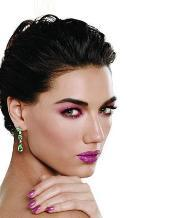


1. SINGLE CELEBRITY CLASSIFICATION TEST
----------------------------------------
Predicted Celebrity: 447
Confidence: 47.13%
Low confidence prediction - might not be in training set

2. MULTI-CELEBRITY DETECTION TEST
----------------------------------------
Results saved to /content/runs/detect/predict
Detected 0 celebrities:
No celebrities detected in the image
Possible reasons:
- Image doesn't contain celebrities from the training set
- Image quality is too low
- Celebrities are too small or partially occluded

Test completed for: img1 10.jpg

CELEBRITY RECOGNITION TESTING MENU
1. Upload single image for testing
2. Upload multiple images for batch testing
3. Test random image from validation set
4. Show model performance summary
5. Visualize detection on uploaded image
6. Exit

Select option (1-6): 1
UPLOAD AND TEST CUSTOM IMAGE
Please select an image file to upload...


Saving img2 10.jpg to img2 10.jpg
Uploaded file: img2 10.jpg


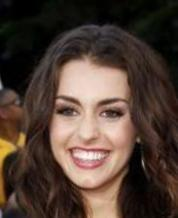


1. SINGLE CELEBRITY CLASSIFICATION TEST
----------------------------------------
Predicted Celebrity: 5239
Confidence: 22.30%
Low confidence prediction - might not be in training set

2. MULTI-CELEBRITY DETECTION TEST
----------------------------------------
Results saved to /content/runs/detect/predict
Detected 0 celebrities:
No celebrities detected in the image
Possible reasons:
- Image doesn't contain celebrities from the training set
- Image quality is too low
- Celebrities are too small or partially occluded

Test completed for: img2 10.jpg

CELEBRITY RECOGNITION TESTING MENU
1. Upload single image for testing
2. Upload multiple images for batch testing
3. Test random image from validation set
4. Show model performance summary
5. Visualize detection on uploaded image
6. Exit

Select option (1-6): 5


Saving img3 10.jpg to img3 10.jpg
VISUALIZING DETECTION RESULTS


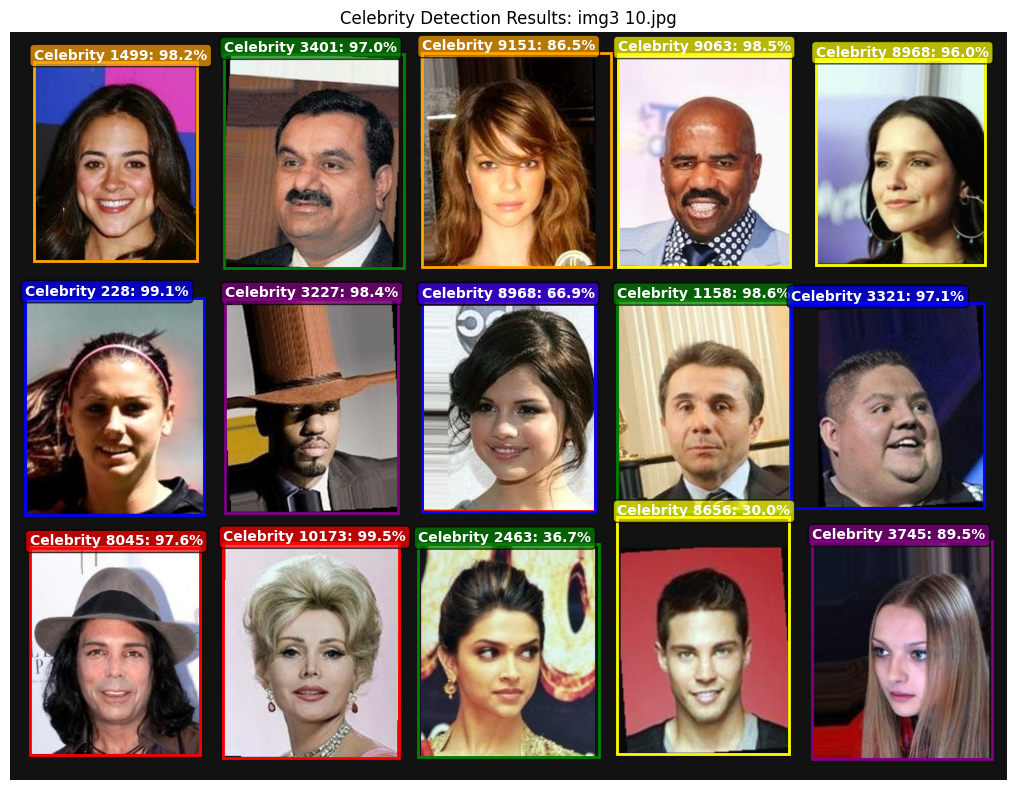


CELEBRITY RECOGNITION TESTING MENU
1. Upload single image for testing
2. Upload multiple images for batch testing
3. Test random image from validation set
4. Show model performance summary
5. Visualize detection on uploaded image
6. Exit

Select option (1-6): 6
Exiting testing menu...


In [ ]:
interactive_testing_menu()